In [7]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl 
details_path = "blackhole_details 50.hdf5"
merger_file  = "blackhole_mergers 50.hdf5"

In [8]:
with h5py.File(details_path, "r") as f:
    bh_ids      = f["unique/id"][:].astype(np.int64)
    first_index = f["unique/first_index"][:].astype(np.int64)
    num_entries = f["unique/num_entries"][:].astype(np.int64)
    all_time    = f["time"][:].astype(float)
    all_mass    = f["mass"][:].astype(float)
    all_mdot    = f["mdot"][:].astype(float)
    all_cs      = f["cs"][:].astype(float)
    all_rho     = f["rho"][:].astype(float)
assert len(all_time) == len(all_mass), "time/mass length mismatch"

In [9]:
with h5py.File(merger_file, "r") as f:
    id_in       = f["id_in"][:].astype(np.int64)
    id_out      = f["id_out"][:].astype(np.int64)
    merger_time = f["time"][:].astype(float)    
    mass_in     = f["mass_in"][:].astype(float)  if "mass_in"  in f else None
    mass_out    = f["mass_out"][:].astype(float) if "mass_out" in f else None


In [10]:
target_id = 113572687160
def find_mergers_for_bh(target_id,
                        id_in, id_out, merger_time,
                        mass_in=None, mass_out=None):
    a_in  = np.asarray(id_in).ravel()
    a_out = np.asarray(id_out).ravel()
    t     = np.asarray(merger_time).ravel().astype(float)

    m_in  = None if mass_in  is None else np.asarray(mass_in).ravel().astype(float)
    m_out = None if mass_out is None else np.asarray(mass_out).ravel().astype(float)

    idx_surv   = np.where(a_out == int(target_id))[0]   # target 作为 survivor
    idx_infall = np.where(a_in  == int(target_id))[0]   # target 作为 infall

    events = []
    for k in idx_surv:
        events.append({
            "t": float(t[k]),
            "role": "survivor",
            "partner_id": int(a_in[k]),
            "partner_mass": (None if m_in is None else float(m_in[k])),
            "row_index": int(k)
        })
    for k in idx_infall:
        events.append({
            "t": float(t[k]),
            "role": "infall",
            "partner_id": int(a_out[k]),
            "partner_mass": (None if m_out is None else float(m_out[k])),
            "row_index": int(k)
        })
    events.sort(key=lambda e: e["t"])
    return events
events = find_mergers_for_bh(
    target_id,
    id_in=id_in, id_out=id_out, merger_time=merger_time,
    mass_in=mass_in, mass_out=mass_out
)

print(f"Target {target_id} number of merging events:", len(events))
if events:
    print("The earliest several:")
    for e in events[:10]:
        pm = "NA" if e["partner_mass"] is None else f"{e['partner_mass']:.3e}"
        print(f"  t={e['t']:.6g}, role={e['role']:<8s}, partner={e['partner_id']}, partner_mass={pm}, row={e['row_index']}")

partner_ids = np.unique([int(e["partner_id"]) for e in events]).astype(np.int64)
print("The number of partners that have merged with the target:", partner_ids.size)
print("Sample of partner ID:", partner_ids[:20])

Target 113572687160 number of merging events: 6
The earliest several:
  t=0.281579, role=survivor, partner=111048078712, partner_mass=6.323e-04, row=171
  t=0.290859, role=survivor, partner=112868582901, partner_mass=2.185e-03, row=198
  t=0.350205, role=survivor, partner=111716977122, partner_mass=2.696e-03, row=357
  t=0.670073, role=survivor, partner=112852002574, partner_mass=3.740e-04, row=1032
  t=0.695671, role=survivor, partner=112782519321, partner_mass=1.290e-02, row=1074
  t=0.717404, role=survivor, partner=112763064508, partner_mass=6.369e-03, row=1113
The number of partners that have merged with the target: 6
Sample of partner ID: [111048078712 111716977122 112763064508 112782519321 112852002574
 112868582901]


In [11]:
target_id = 113572687160  

events = find_mergers_for_bh(
    target_id,
    id_in=id_in, id_out=id_out, merger_time=merger_time,
    mass_in=mass_in, mass_out=mass_out
)

partner_ids = np.unique([int(e["partner_id"]) for e in events]).astype(np.int64)
ids_to_plot = np.r_[np.int64(target_id), partner_ids]   # ★ 关键行

print("The ID to be drawn:", ids_to_plot.tolist())


The ID to be drawn: [113572687160, 111048078712, 111716977122, 112763064508, 112782519321, 112852002574, 112868582901]


In [21]:
import numpy as np

def partners_of(bh, id_in, id_out):
    bh = int(bh)
    id_in = np.asarray(id_in, dtype=np.int64).ravel()
    id_out = np.asarray(id_out, dtype=np.int64).ravel()
    m = (id_in == bh) | (id_out == bh)
    if not np.any(m):
        return np.array([], dtype=np.int64)
    a = id_in[m]
    b = id_out[m]
    p = np.where(a == bh, b, a)
    return np.unique(p.astype(np.int64))

def two_groups(target_id, id_in, id_out, include_target_in_A=True):
    target_id = int(target_id)

    # Group A: 直接 partner（第一层）
    groupA = set(partners_of(target_id, id_in, id_out).tolist())
    if include_target_in_A:
        groupA.add(target_id)

    # Group B: 通过 Group A 间接连到的（第二层）
    groupB = set()
    for bh in groupA:
        for p in partners_of(bh, id_in, id_out).tolist():
            p = int(p)
            if p != target_id and p not in groupA:
                groupB.add(p)

    groupA = np.array(sorted(groupA), dtype=np.int64)
    groupB = np.array(sorted(groupB), dtype=np.int64)
    return groupA, groupB

In [23]:
groupA, groupB = two_groups(
    target_id=113572687160,
    id_in=id_in,
    id_out=id_out,
)

In [24]:
print("========== GROUP A (Direct Mergers) ==========")
print(f"Count: {len(groupA)}")
print(groupA)

print("\n========== GROUP B (Indirect Mergers) ==========")
print(f"Count: {len(groupB)}")
print(groupB)

========== GROUP A (Direct Mergers) ==========
Count: 7
[111048078712 111716977122 112763064508 112782519321 112852002574
 112868582901 113572687160]

========== GROUP B (Indirect Mergers) ==========
Count: 2
[108832238015 111941813330]


In [25]:
def split_major_minor(ids_to_plot, target_id, id_in, id_out, include_target=True):
    ids_set = set(map(int, np.asarray(ids_to_plot, dtype=np.int64).ravel().tolist()))
    target_id = int(target_id)

    partners = set(map(int, partners_of(target_id, id_in, id_out)))
    major = (partners | {target_id}) if include_target else partners
    major = major & ids_set
    minor = ids_set - major

    return sorted(major), sorted(minor)

major_group, minor_group = split_major_minor(
    ids_to_plot=ids_to_plot,
    target_id=target_id,
    id_in=id_in,
    id_out=id_out,
    include_target=True,
)

print("Major group N =", len(major_group))
print(major_group)
print("\nMinor group N =", len(minor_group))
print(minor_group)

Major group N = 7
[111048078712, 111716977122, 112763064508, 112782519321, 112852002574, 112868582901, 113572687160]

Minor group N = 0
[]


In [26]:
import importlib
import bh_tracks_plot as bp
importlib.reload(bp)

<module 'bh_tracks_plot' from '/Users/tianruizhang/bh_tracks_plot.py'>

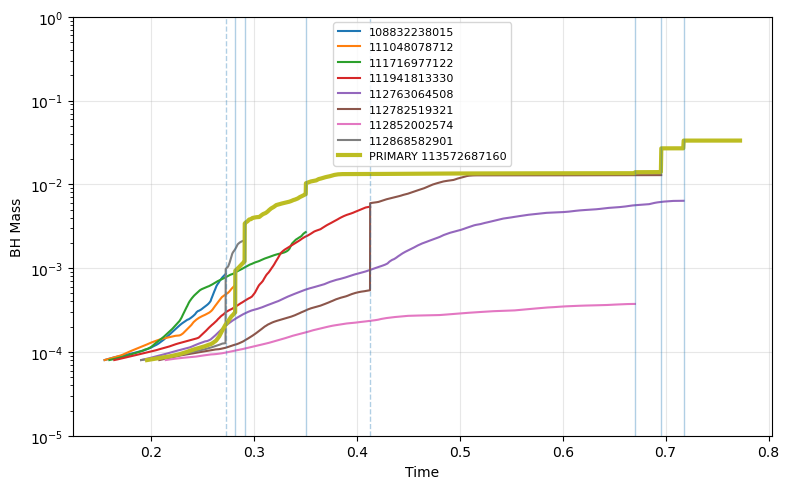

In [27]:
fig, ax = bp.plot_mass(
    groupA=groupA, groupB=groupB,
    bh_ids=bh_ids, first_index=first_index, num_entries=num_entries,
    all_time=all_time, all_mass=all_mass,
    id_in=id_in, id_out=id_out, merger_time=merger_time,
    show_mergers=True,
    ylog=True,
    ylim=(1e-5, 1e0),
)
plt.show()

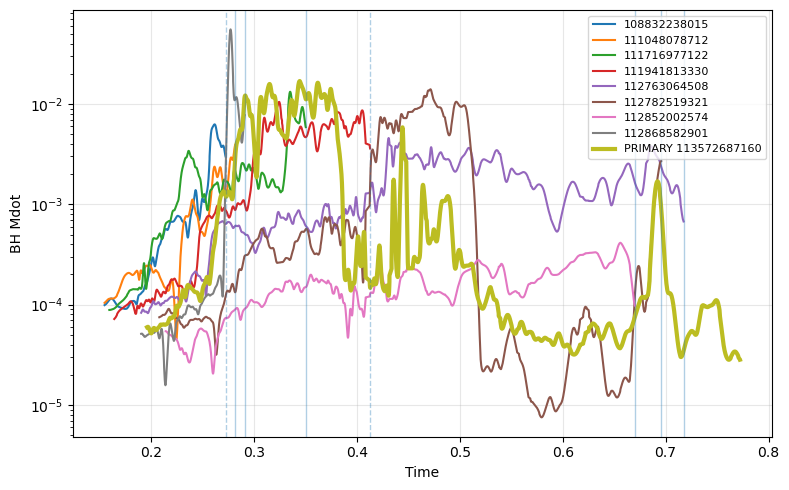

In [28]:
fig, ax = bp.plot_mdot(
    groupA=groupA, groupB=groupB,
    bh_ids=bh_ids, first_index=first_index, num_entries=num_entries,
    all_time=all_time, all_mdot=all_mdot,
    all_mass=all_mass,  # 用来自动选 primary（建议给）
    id_in=id_in, id_out=id_out, merger_time=merger_time,
    show_mergers=True,
    ylog=True,
    denoise=True, tv_weight=1000, tv_n_iter=200
)
plt.show()

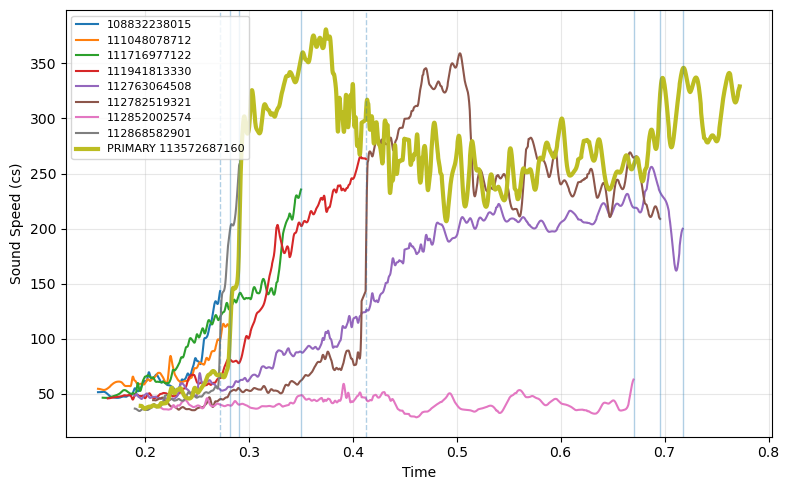

In [30]:
fig, ax = bp.plot_cs(
    groupA=groupA, groupB=groupB,
    bh_ids=bh_ids, first_index=first_index, num_entries=num_entries,
    all_time=all_time, all_cs=all_cs,
    all_mass=all_mass,
    id_in=id_in, id_out=id_out, merger_time=merger_time,
    show_mergers=True,
    ylog=False,
    denoise=True, tv_weight=1000, tv_n_iter=200
)
plt.show()

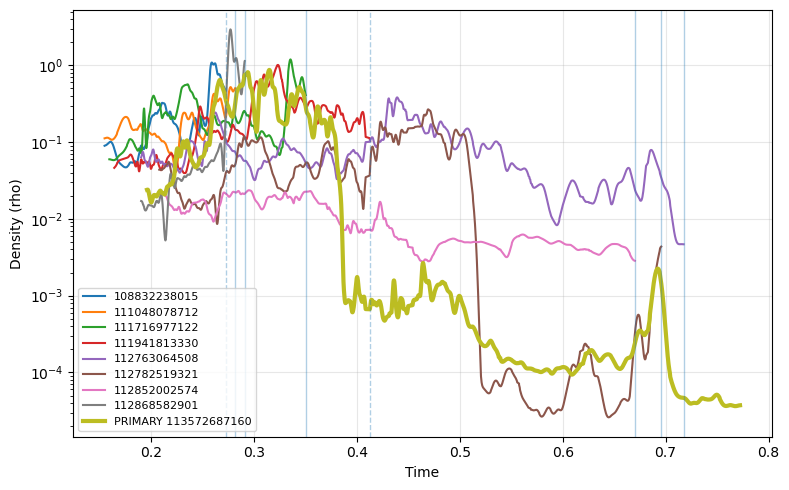

In [33]:
fig, ax = bp.plot_rho(
    groupA=groupA, groupB=groupB,
    bh_ids=bh_ids, first_index=first_index, num_entries=num_entries,
    all_time=all_time, all_rho=all_rho,
    all_mass=all_mass,
    id_in=id_in, id_out=id_out, merger_time=merger_time,
    show_mergers=True,
    ylog=True,
    denoise=True, tv_weight=1000, tv_n_iter=200
)
plt.show()

In [31]:
import numpy as np

ids_to_plot = np.unique(np.concatenate([groupA, groupB])).astype(np.int64)
print("ids_to_plot N =", len(ids_to_plot))
print(ids_to_plot)

ids_to_plot N = 9
[108832238015 111048078712 111716977122 111941813330 112763064508
 112782519321 112852002574 112868582901 113572687160]


In [15]:
def final_mass_of(bh, bh_ids, first_index, num_entries, all_mass):
    bh = int(bh)
    pos = {int(x): i for i, x in enumerate(np.asarray(bh_ids, dtype=np.int64).ravel())}
    if bh not in pos:
        return np.nan
    i = pos[bh]
    s = int(first_index[i])
    n = int(num_entries[i])
    if n <= 0:
        return np.nan
    return float(np.asarray(all_mass, dtype=float)[s + n - 1])

def primary_bh_in_groupA(groupA, bh_ids, first_index, num_entries, all_mass):
    groupA = np.asarray(groupA, dtype=np.int64).ravel()
    masses = np.array([final_mass_of(b, bh_ids, first_index, num_entries, all_mass) for b in groupA], dtype=float)
    if masses.size == 0 or not np.isfinite(masses).any():
        return None
    return int(groupA[np.nanargmax(masses)])